In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from src.bee_classes import Word, SolutionList, Puzzle

# Load data from local CSV files (created by main analysis notebook)
df_db = pd.read_csv('data/db.csv')
df_mw = pd.read_csv('data/mw.csv')
df_lw = pd.read_csv('data/lw.csv')

# Optional: load ML dataset for richer analysis
df_ml = pd.read_csv('data/ml_word_dataset.csv')

print(f"✅ Data loaded")
print(f"   Solutions DB: {len(df_db)} puzzles")
print(f"   Missed words: {len(df_mw)} dates")
print(f"   Last words: {len(df_lw)} dates")
print(f"   ML dataset: {len(df_ml)} words")

✅ Data loaded
   Solutions DB: 2793 puzzles
   Missed words: 2000 dates
   Last words: 1000 dates
   ML dataset: 294938 words


## Prepare Merged DataFrame for Time Series Analysis

In [3]:
# Reconstruct df_merged for historical plots
def create_alphagram_nw_pt_dict(row):
    try:
        solution = row['solution']
        s = SolutionList(solution.split(' '))
        d = {}
        for k,v in s.alphagram_dictionary.items():
            d[k] = [w.word for w in v]
        return d, int(s.points), int(s.nwords)
    except:
        return None, None, None

# Add points and nwords to both dataframes
df_db[['alpha_dict','points','nwords']] = df_db.apply(create_alphagram_nw_pt_dict, axis=1, result_type="expand")
df_mw[['alpha_dict','points','nwords']] = df_mw.apply(create_alphagram_nw_pt_dict, axis=1, result_type="expand")

# Prepare missed words dataframe
df_mw['nwords'] = df_mw['nwords'].fillna(0)
df_mw['points'] = df_mw['points'].fillna(0)
df_mw['solution'] = df_mw['solution'].fillna('')
df_mw['qb'] = df_mw['nwords'] == 0  # Queen Bee = no missed words
df_mw['datetime'] = pd.to_datetime(df_mw['date'], format='%Y-%m-%d')

# Merge databases
df_merged = df_db.merge(df_mw, how='inner', on='date', suffixes=('_db', '_mw'))

print(f"✅ Merged dataframe created: {len(df_merged)} rows")
print(f"   Date range: {df_merged['date'].min()} to {df_merged['date'].max()}")
print(f"   Queen Bees: {df_merged['qb'].sum()} ({df_merged['qb'].mean()*100:.1f}%)")

✅ Merged dataframe created: 1860 rows
   Date range: 2020-11-27 to 2025-12-30
   Queen Bees: 1236 (66.5%)


## Performance Over Time Plots

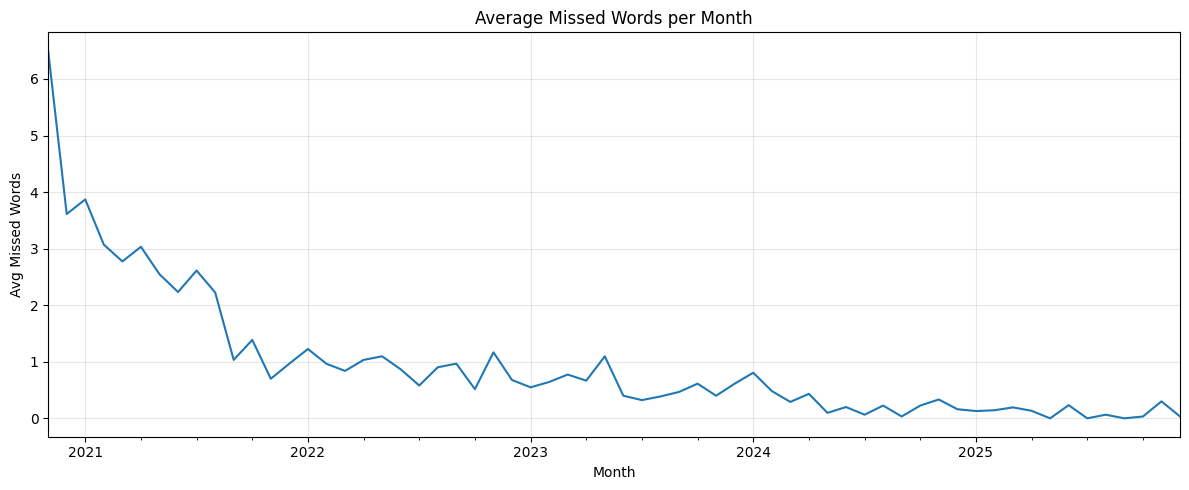

In [4]:
# Average missed words per month
plt.figure(figsize=(12, 5))
df_merged.groupby(pd.PeriodIndex(df_merged['datetime'], freq="M"))['nwords_mw'].mean().plot()
plt.title('Average Missed Words per Month')
plt.ylabel('Avg Missed Words')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

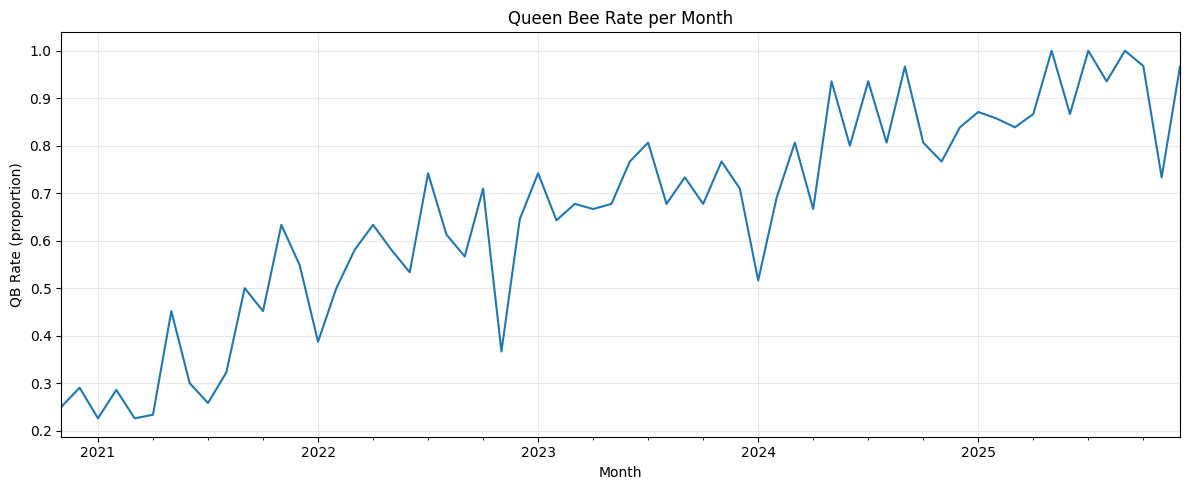

In [5]:
# Queen Bee rate per month
plt.figure(figsize=(12, 5))
df_merged.groupby(pd.PeriodIndex(df_merged['datetime'], freq="M"))['qb'].mean().plot()
plt.title('Queen Bee Rate per Month')
plt.ylabel('QB Rate (proportion)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Puzzle Difficulty Analysis

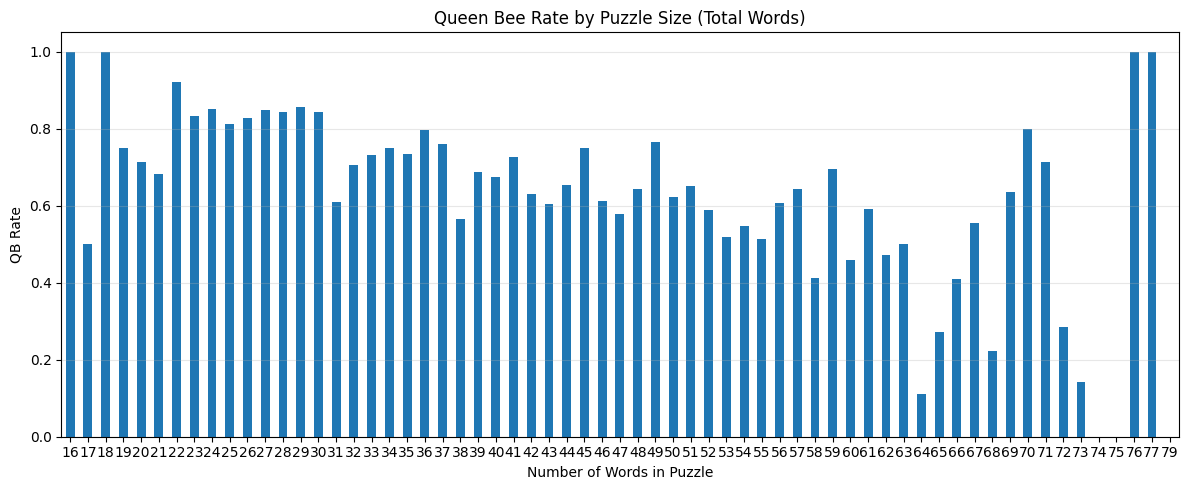

In [6]:
# Queen Bee rate by puzzle size (number of words)
plt.figure(figsize=(12, 5))
df_merged.groupby(df_merged['nwords_db'])['qb'].mean().plot(kind='bar')
plt.title('Queen Bee Rate by Puzzle Size (Total Words)')
plt.ylabel('QB Rate')
plt.xlabel('Number of Words in Puzzle')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

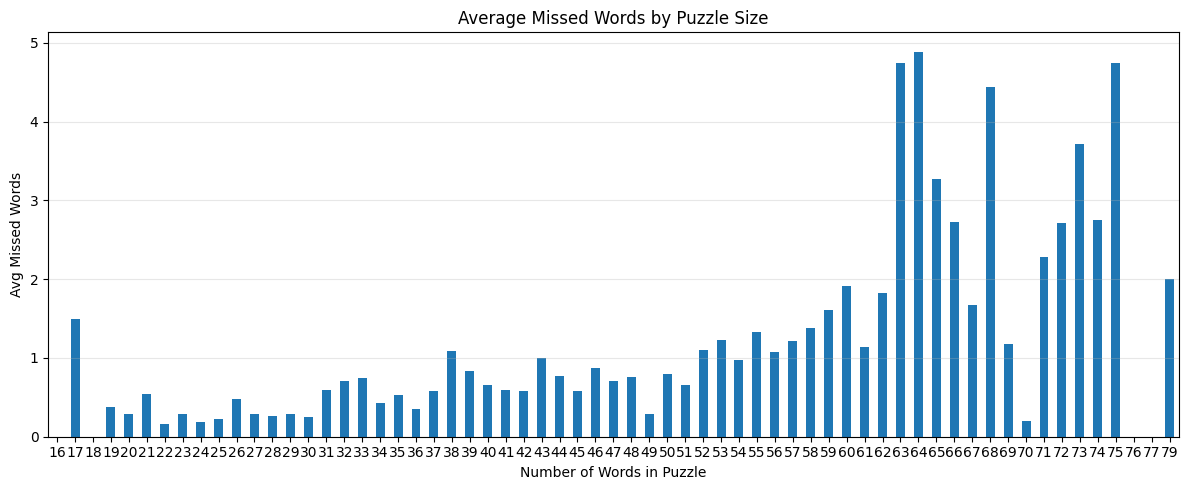

In [7]:
# Average missed words by puzzle size
plt.figure(figsize=(12, 5))
df_merged.groupby(df_merged['nwords_db'])['nwords_mw'].mean().plot(kind='bar')
plt.title('Average Missed Words by Puzzle Size')
plt.ylabel('Avg Missed Words')
plt.xlabel('Number of Words in Puzzle')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

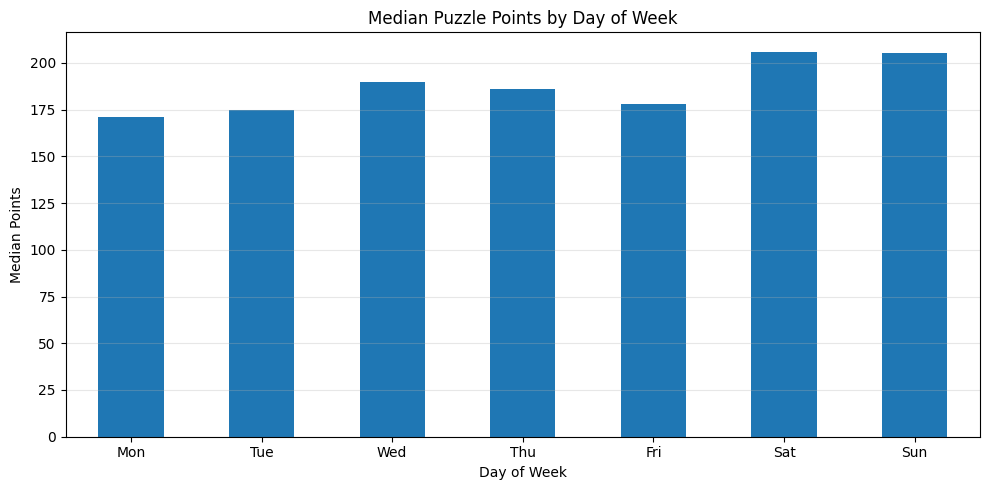

In [8]:
# Median puzzle points by day of week
plt.figure(figsize=(10, 5))
df_merged.groupby(df_merged['datetime'].dt.dayofweek)['points_db'].median().plot(kind='bar')
plt.title('Median Puzzle Points by Day of Week')
plt.ylabel('Median Points')
plt.xlabel('Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Word Difficulty Analysis (using ML dataset)

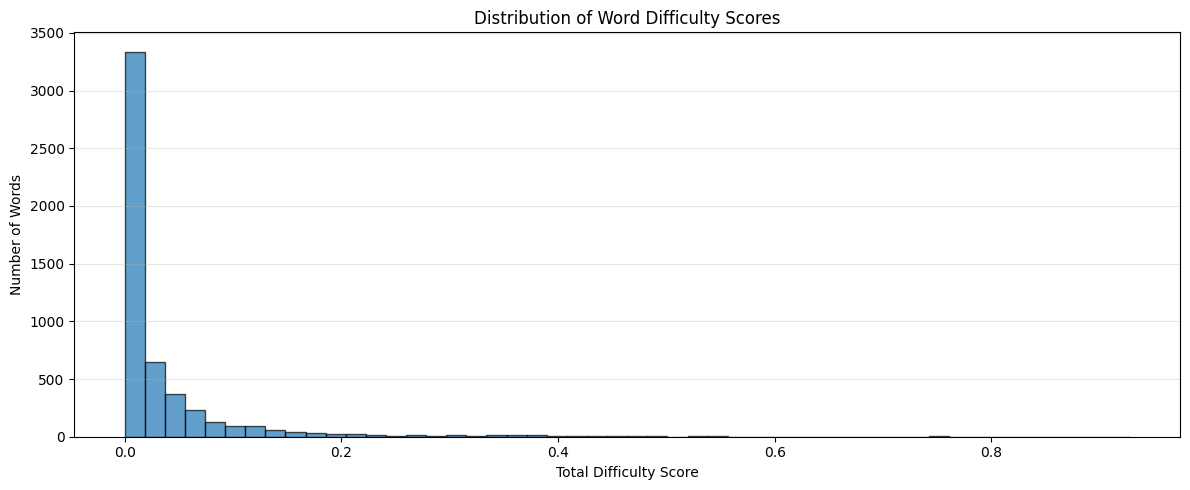

Words with difficulty scores: 5240
Mean difficulty: 0.03
Median difficulty: 0.01


In [9]:
# Difficulty score distribution
df_ml_with_difficulty = df_ml[df_ml['total_difficulty'] > 0]

plt.figure(figsize=(12, 5))
plt.hist(df_ml_with_difficulty['total_difficulty'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Difficulty Scores')
plt.xlabel('Total Difficulty Score')
plt.ylabel('Number of Words')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Words with difficulty scores: {len(df_ml_with_difficulty)}")
print(f"Mean difficulty: {df_ml_with_difficulty['total_difficulty'].mean():.2f}")
print(f"Median difficulty: {df_ml_with_difficulty['total_difficulty'].median():.2f}")

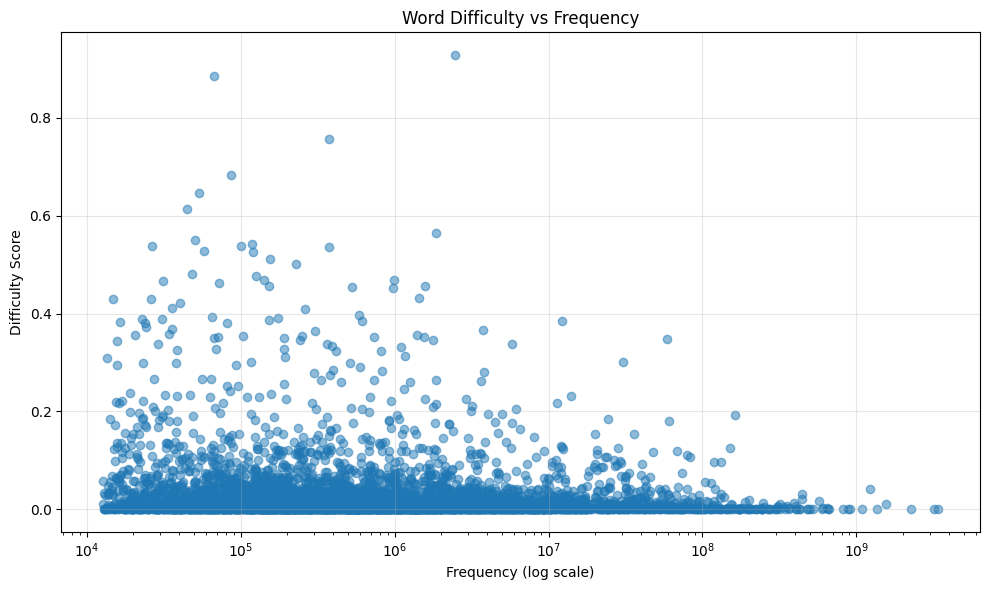

Correlation: -0.043


In [10]:
# Difficulty vs Frequency (for words with both)
df_freq_diff = df_ml_with_difficulty[df_ml_with_difficulty['frequency'].notna()].copy()

plt.figure(figsize=(10, 6))
plt.scatter(df_freq_diff['frequency'], df_freq_diff['total_difficulty'], alpha=0.5)
plt.xscale('log')
plt.title('Word Difficulty vs Frequency')
plt.xlabel('Frequency (log scale)')
plt.ylabel('Difficulty Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation: {df_freq_diff[['frequency', 'total_difficulty']].corr().iloc[0,1]:.3f}")

<Figure size 1000x600 with 0 Axes>

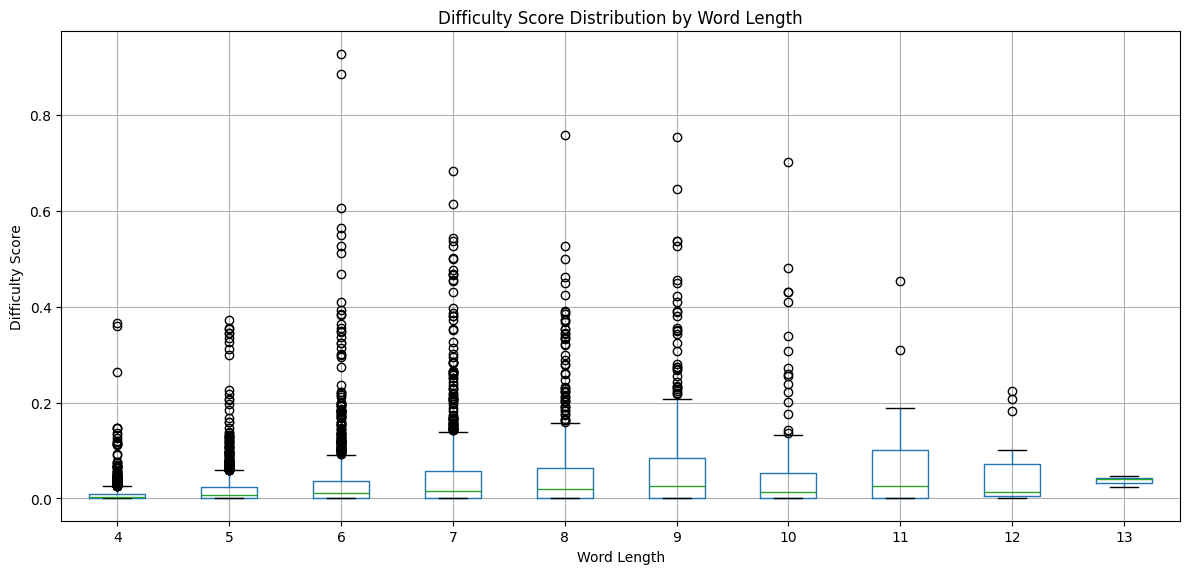

In [11]:
# Difficulty by word length
plt.figure(figsize=(10, 6))
df_ml_with_difficulty.boxplot(column='total_difficulty', by='word_length', figsize=(12, 6))
plt.title('Difficulty Score Distribution by Word Length')
plt.suptitle('')  # Remove default title
plt.xlabel('Word Length')
plt.ylabel('Difficulty Score')
plt.tight_layout()
plt.show()

## Custom Analysis Playground

Use the cells below for ad-hoc queries and exploration.

In [12]:
# Example: Find hardest valid words you haven't encountered
valid_unencountered = df_ml[
    (df_ml['validity'] == 'valid') & 
    (df_ml['total_difficulty'] == 0) &
    (df_ml['has_been_played'] == True)
].sort_values('frequency', ascending=True).head(50)

print("50 rarest valid words you've never missed or struggled with:")
print(valid_unencountered[['word', 'alphagram', 'frequency', 'word_length']])

50 rarest valid words you've never missed or struggled with:
                 word alphagram  frequency  word_length
124865     INHIBITIVE   BEHINTV    12714.0           10
264637        TOPKNOT     KNOPT    12855.0            7
26902       BIAXIALLY    ABILXY    12858.0            9
123371        INANELY    AEILNY    12924.0            7
17446        ATTUNING    AGINTU    13108.0            8
191629      PARATROOP     AOPRT    13145.0            9
91948          FLUFFS      FLSU    13214.0            6
89031          FEUDED      DEFU    13216.0            6
260959         THIEVE     EHITV    13240.0            6
46569           CHOKY     CHKOY    13245.0            5
105877      GRANDBABY   ABDGNRY    13293.0            9
271579       UNBOXING   BGINOUX    13394.0            8
92990          FORBAD    ABDFOR    13414.0            6
103005          GLUEY     EGLUY    13442.0            5
102682      GLITCHING   CGHILNT    13477.0            9
17176   ATTAINABILITY   ABILNTY    13541.0 

In [13]:
# Example: Recent performance trend (last 90 days)
recent_cutoff = pd.Timestamp.now() - pd.Timedelta(days=90)
df_recent = df_merged[df_merged['datetime'] >= recent_cutoff]

print(f"Last 90 days performance:")
print(f"  Total puzzles: {len(df_recent)}")
print(f"  Queen Bees: {df_recent['qb'].sum()} ({df_recent['qb'].mean()*100:.1f}%)")
print(f"  Avg missed words: {df_recent['nwords_mw'].mean():.1f}")
print(f"  Median missed words: {df_recent['nwords_mw'].median():.0f}")

Last 90 days performance:
  Total puzzles: 90
  Queen Bees: 80 (88.9%)
  Avg missed words: 0.1
  Median missed words: 0
